# Tutorial 1a: Optiland for Beginners


*Last verified against Optiland v0.6.1.*

This tutorial describes the basics of Optiland. In particular, the following topics are covered:

- Basic lens entry
- Material definition and selection
- Aperture, field and wavelength selection
- Checking a system for common mistakes
- Drawing a lens in 2D and 3D

## A complete lens, first

Below is a full, working optical system: a singlet with a 25 mm entrance pupil, one on-axis field, and one wavelength. Run it and you get a ray-traced layout. Everything after this cell explains what each line does — but the whole program is already here, and it is not long.

In [1]:
import numpy as np

from optiland import optic

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

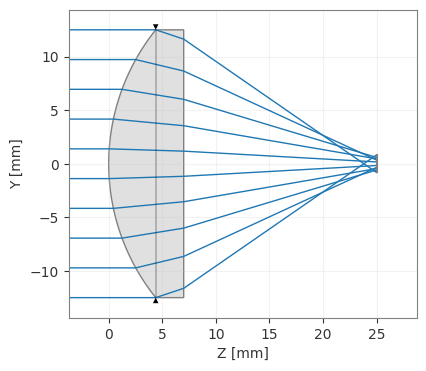

In [3]:
singlet = optic.Optic()

# define surfaces
singlet.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
singlet.surfaces.add(index=1, radius=20, thickness=7, is_stop=True, material="N-SF11")
singlet.surfaces.add(index=2, radius=np.inf, thickness=18)
singlet.surfaces.add(index=3)

# define aperture
singlet.set_aperture(aperture_type="EPD", value=25)

# define fields
singlet.fields.set_type(field_type="angle")
singlet.fields.add(y=0)

# define wavelengths
singlet.wavelengths.add(value=0.5, is_primary=True)

# draw it
singlet.draw(num_rays=10)

> **Note:**  
The `draw()` method returns the matplotlib figure and axes.  
When running Optiland in a script, you must explicitly call `plt.show()` or `fig.show()` to display the plot.  

In Jupyter notebooks, figures are displayed automatically.

That is the entire program. The rest of this tutorial takes it apart line by line.

> **One convention to internalize before you read further:** a surface's `thickness` and `material` describe the space that *follows* it, not the surface itself. So `surfaces.add(index=1, thickness=7, material="N-SF11")` means *7 mm of N-SF11 glass between surface 1 and surface 2*.

<figure style="text-align: left;">
  <img src="../images/after_rule.svg" alt="A surface's thickness and material describe the space after it" style="width: 700px; max-width: 100%;">
</figure>

The full set of conventions — sign conventions, units, the object/image surface rule, and stop vs. aperture vs. pupil — lives on the [Conventions](../conventions.rst) page. It is worth the five minutes.

## Defining a lens, in detail:

### Create the optic:

In Optiland, lenses are instances of the "Optic" class. The process for defining a lens starts with creating an empty "Optic" object as follows:

In [4]:
lens = optic.Optic()

### Add the object surface:

We now want to populate the lens object with surfaces. Let's first add the object surface, which will be at infinity and will have a radius of infinity, i.e. it is a plane. We add the surface by calling the "add_surface" method. We must specify the index as 0 to indicate this is the first surface.

In [5]:
lens.surfaces.add(index=0, radius=np.inf, thickness=np.inf)

### Add a lens:

Let's now add a singlet lens:

- Material: N-SF11
- Thickness: 7 mm
- Radius side 1: 20 mm
- Radius side 2: infinity
- Stop surface: 1

Optiland defines lenses one surface at a time, so each side of the lens is a separate surface — indices 1 and 2 here, following the object plane at index 0.

Because `thickness` and `material` describe the space *after* a surface (the "after" rule above), surface 1 carries `thickness=7, material="N-SF11"` — the glass — and surface 2 carries `thickness=18`, the air gap to the image plane. Surface 2 needs no material: air is the default. See [Conventions](../conventions.rst) for the sign conventions and units that go with this.


In [6]:
lens.surfaces.add(index=1, thickness=7, radius=20, is_stop=True, material="N-SF11")
lens.surfaces.add(index=2, radius=np.inf, thickness=18)

### Add image plane:

Lastly, let's add the image plane. By default, the radius is infinity, so we can exclude it. We also can omit thickness, as there are no surfaces beyond the image. We need only to define the index, which is 3.

In [7]:
lens.surfaces.add(index=3)

### Define aperture:

Now, we can define the aperture of the system. Let's choose entrance pupil diameter (EPD) as the aperture type with a value of 25 mm.

The options for aperture type are:

- 'EPD' - entrance pupil diameter
- 'imageFNO' - image-space F-number
- 'objectNA' - object-space numerical aperture
- 'float_by_stop_size' - the aperture size _floats_ with the size of the stop _diameter_, which is defined by the `value` argument.

In [8]:
lens.set_aperture(aperture_type="EPD", value=25)

### Define fields:

Let's add the fields of the lens. We'll keep it simple and add a single field of type "angle" with a value of 0.

The options for field types are:

- 'angle' - the angle of the field in object space
- 'object_height' - the height of the object
- 'paraxial_image_height' - the image height of a paraxial chief ray
- 'real_image_height' - the image height of a real chief ray

In [9]:
lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)

### Define wavelengths:

Lastly, let's define the wavelengths of the system. We define a single wavelength at 0.5 µm. Similar to fields, wavelengths can be assigned a weight to emphasize specific spectral regions.

In [10]:
lens.wavelengths.add(value=0.5, is_primary=True)

### Sanity-check the lens:

Before viewing or tracing rays through the lens, it is good practice to run `check_system`. It inspects the `Optic` for the mistakes newcomers hit most often (a missing wavelength, an undefined aperture, a stop that was never marked, ...) and reports each one with a runnable fix. `report.ok` is `True` once there are no errors left.

In [11]:
from optiland.diagnostics import check_system

report = check_system(lens)
report

DiagnosticReport(errors=0, warnings=0)

### View the lens:

Let's view the lens in 2D. We can do this by calling the `draw` method.

Note that you can also pass a `projection` argument, allowing you to plot in the `"YZ"` plane (default), `"XZ"` plane, or `"XY"` plane.

The 2D visualization is now interactive! You can hover over surfaces, lenses, and ray bundles to get more information. You can also customize the look and feel of the plots using themes. See the gallery for an example of how to use themes.

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

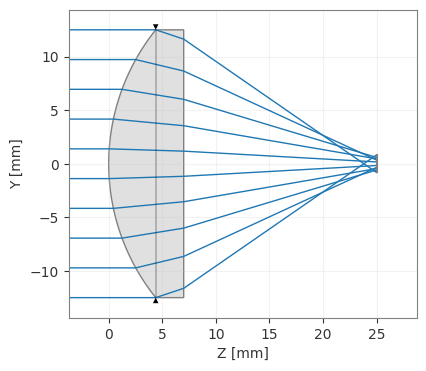

In [12]:
lens.draw(num_rays=10)

Finally, we view the lens in 3D using the "draw3D" function. Note that this opens a new window.

In [13]:
lens.draw3D()

The 3D view opens in a separate VTK window rather than inline, so here is what it looks like:
<figure style="text-align: left;">
  <img src="../images/singlet.png" alt="Singlet" style="width: 500px;">
</figure>

## Where to go next

You can now build an optical system from scratch, define its aperture, fields and wavelengths, check it for common mistakes, and view it in 2D and 3D. That is enough to enter any sequential system Optiland supports.

Next steps, in order of usefulness:

- **[Tutorial 1b — Lens Properties and Prescription](Tutorial_1b_Lens_Properties_and_Prescription.ipynb)** — read the first-order properties (EFL, f/#, pupils) back out of a system.
- **[Tutorial 1e — Design a Doublet End to End](Tutorial_1e_Design_a_Doublet_End_to_End.ipynb)** — one design carried from requirements through analysis, optimization and tolerancing.
- **[Conventions](../conventions.rst)** — the model behind every tutorial, in one page.
- **[How do I ...?](../how_do_i.rst)** — a task-shaped index: find your question, get the notebook that answers it.